In [1]:
!pip uninstall -y protobuf tensorflow mediapipe


Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0


In [2]:
!pip install protobuf==3.20.3
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, which is not installed.
google-cloud-firestore 2.27.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
grpc-google-iam-v1 0.14.4 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
googleapis-common-protos 1.75.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
google-cloud-monitoring 2.30.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
wandb 0.27.0 requires protobuf!=5.28.0,!=5.29.0,<8,>4.21.0, but you have protobuf 3.20.3 which is incompat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 27.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, which is not installed.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.17 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.


In [1]:
import cv2
import numpy as np
import mediapipe as mp
from PIL import Image
import matplotlib.pyplot as plt

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

In [20]:
from PIL import ImageOps

def load_image_corrected(path: str) -> Image.Image:
    img = Image.open(path).convert("RGB")
    # Applies EXIF rotation metadata so orientation is correct
    img = ImageOps.exif_transpose(img)
    return img

class MaskGenerator:
    def __init__(self):
        self.hands = mp_hands.Hands(
            static_image_mode=True,
            max_num_hands=1,
            min_detection_confidence=0.5
        )

    def _extend_point(self, base, tip, scale=1.5):
        dx = tip[0] - base[0]
        dy = tip[1] - base[1]
        return [int(tip[0] + dx * (scale - 1)),
                int(tip[1] + dy * (scale - 1))]

    def generate(self, pil_image: Image.Image, padding: int = 20) -> Image.Image:
        img_rgb = np.array(pil_image.convert("RGB"))
        h, w, _ = img_rgb.shape
        mask = np.zeros((h, w), dtype=np.uint8)

        results = self.hands.process(img_rgb)
        if not results.multi_hand_landmarks:
            print("No hand detected.")
            return Image.fromarray(mask)

        lm = results.multi_hand_landmarks[0].landmark
        pts = [[int(lm[i].x * w), int(lm[i].y * h)] for i in range(21)]

        # Palm base ring — these 6 points define the core palm shape
        # 0=wrist, 1=thumb_cmc, 5=index_mcp, 9=middle_mcp, 13=ring_mcp, 17=pinky_mcp
        palm_ids = [1, 5, 9, 13, 17]   # exclude wrist (0) — it's the notch culprit

        # Wrist: push it down from midpoint of palm base instead of using raw lm[0]
        palm_mid_x = int(np.mean([pts[i][0] for i in palm_ids]))
        palm_mid_y = int(np.mean([pts[i][1] for i in palm_ids]))
        wrist_extended = self._extend_point(
            [palm_mid_x, palm_mid_y], pts[0], scale=1.2  # gentle extension, not raw point
        )

        # Fingertip extensions — each tip pushed away from its base
        finger_pairs = [(1,4), (5,8), (9,12), (13,16), (17,20)]
        extended_tips = [self._extend_point(pts[b], pts[t], scale=1.3)
                        for b, t in finger_pairs]

        # Final point set: palm ring + extended wrist + extended tips
        all_points = (
            [pts[i] for i in palm_ids] +
            [wrist_extended] +
            extended_tips
        )

        points_np = np.array(all_points, dtype=np.int32)
        hull = cv2.convexHull(points_np)
        cv2.fillPoly(mask, [hull], 255)

        # Mild morphology — just to smooth edges, not close gaps
        kernel = np.ones((20, 20), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        mask = cv2.dilate(mask, np.ones((10, 10), np.uint8), iterations=1)

        return Image.fromarray(mask)

    def visualize(self, pil_image: Image.Image, mask: Image.Image):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(pil_image); axes[0].set_title("Original")
        axes[1].imshow(mask, cmap='gray'); axes[1].set_title("Mask")
        # Overlay: green tint on masked region
        overlay = np.array(pil_image.convert("RGB")).copy()
        overlay[np.array(mask) > 0] = [0, 200, 0]
        axes[2].imshow(overlay); axes[2].set_title("Overlay")
        plt.tight_layout(); plt.show()


In [11]:
import torch
def pil_to_tensor(pil_img: Image.Image)->torch.Tensor:
  img_np = np.array(pil_img.convert("RGB"))

  img_t = torch.from_numpy(img_np).float()
  img_t = img_t.permute(2, 0, 1)
  img_t /= 255.0
  img_t = img_t.unsqueeze(0)
  return img_t
def tensor_to_pil(t_img: torch.Tensor)->Image.Image:
  t_img = t_img.squeeze(0)
  np_back_img = (t_img.permute(1,2,0).numpy() * 255).astype(np.uint8)

  pil_back_img = Image.fromarray(np_back_img)
  return pil_back_img

In [12]:
class ImagePreprocessor:
  def __init__(self, size: int = 512):
    self.size = size

  def prepare_image(self, pil_img: Image.Image) -> torch.Tensor:
    self.original_size = pil_img.size

    img = pil_img.convert("RGB").resize((self.size, self.size), Image.LANCZOS)

    t = pil_to_tensor(img)

    t = (t * 2.0) - 1.0

    return t

  def prepare_mask(self, pil_mask: Image.Image) ->torch.Tensor:
    mask = pil_mask.convert("L").resize((self.size, self.size), Image.NEAREST)
    mask_tensor = torch.from_numpy(np.array(mask)).float() / 255.0
    return mask_tensor.unsqueeze(0).unsqueeze(0)

  def restore_size(self, t: Image.Image) -> Image.Image:
    return t.resize(self.original_size, Image.LANCZOS)

In [13]:
!pip install diffusers transformers accelerate torch torchvision -q

In [14]:
from diffusers import StableDiffusionInpaintPipeline

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Running on: {device} | dtype: {dtype}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Running on: cuda | dtype: torch.float16


In [15]:
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=dtype,
    safety_checker=None        # removes the NSFW filter — speeds up inference
)
pipe = pipe.to(device)

# Memory optimization — crucial for Colab
pipe.enable_attention_slicing()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'diffusers.pipelin

In [16]:
from PIL import Image
def run_inpainting(
    original_image: Image.Image,
    mask_image: Image.Image,
    prompt: str,
    negative_prompt: str = "blurry, distorted, extra fingers, deformed, low quality, cartoon",
    strength: float = 0.99,
    guidance_scale: float = 7.5,
    num_steps: int = 20
) -> Image.Image:

    # SD needs exactly 512x512
    image_512 = original_image.convert("RGB").resize((512, 512), Image.LANCZOS)
    mask_512  = mask_image.convert("L").resize((512, 512), Image.NEAREST)

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=image_512,
        mask_image=mask_512,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=num_steps
    ).images[0]

    # Restore original size
    result = result.resize(original_image.size, Image.LANCZOS)
    return result

Saving 6th.jpg to 6th (9).jpg


  0%|          | 0/19 [00:00<?, ?it/s]

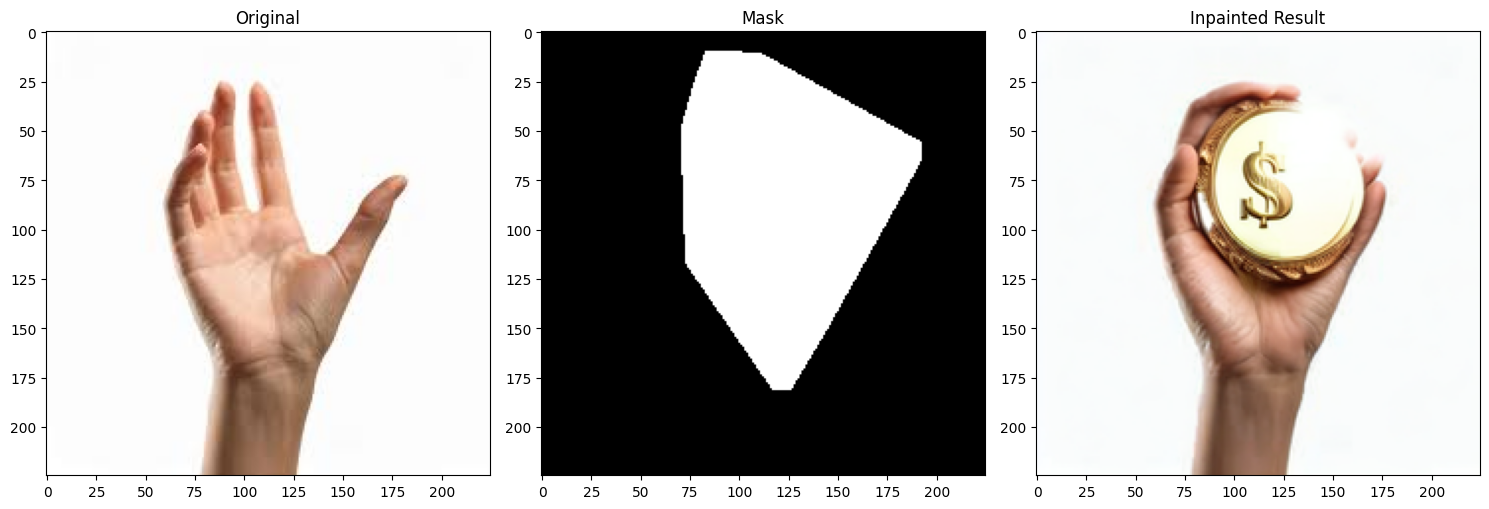

  0%|          | 0/19 [00:00<?, ?it/s]

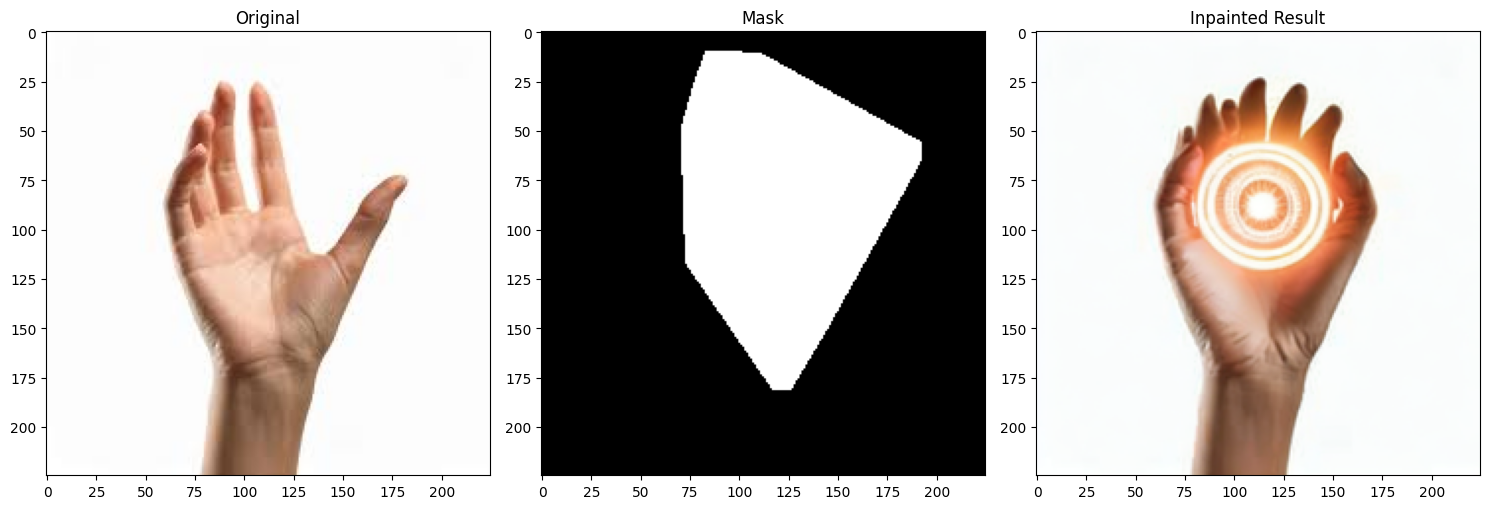

  0%|          | 0/19 [00:00<?, ?it/s]

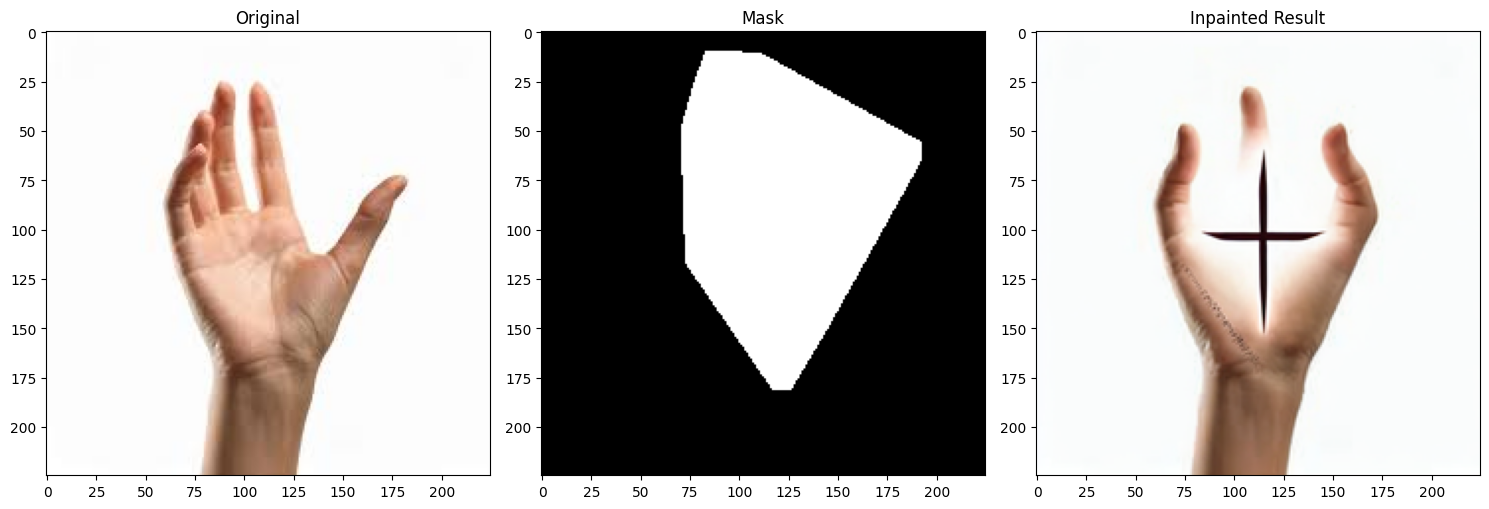

In [32]:
from PIL import Image
from google.colab import files
f = files.upload()

# Your classes from Block 2
mask_gen   = MaskGenerator()
preprocessor = ImagePreprocessor()
def full_pipeline(image_path: str, prompt: str) -> Image.Image:
    # 1. Load
    original = load_image_corrected(image_path)

    # 2. Generate mask from MediaPipe
    mask = mask_gen.generate(original, padding=20)

    # 3. Visualize before sending to SD — catch bad masks early
    # mask_gen.visualize(original, mask)

    # 4. Run inpainting
    result = run_inpainting(original, mask, prompt)

    # 5. Show result
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original);        axes[0].set_title("Original")
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title("Mask")
    axes[2].imshow(result);           axes[2].set_title("Inpainted Result")
    plt.tight_layout()
    plt.show()

    return result

# Test it

result = full_pipeline("6th.jpg", "a shiny gold coin placed in the center of the palm, studio lighting, 8k")
# Visual 2
result2 = full_pipeline("6th.jpg",
    "a glowing iron man arc reactor embedded in the palm, cinematic lighting, photorealistic")

# Visual 3
result3 = full_pipeline("6th.jpg",
    "a magical glowing rune tattoo on the palm, fantasy art, highly detailed")
result.save("output_coin_5.png")
result2.save("output_arcreactor_5.png")
result3.save("output_rune_5.png")

In [33]:
!pip install gradio -q
import gradio as gr
from PIL import ImageOps

def gradio_pipeline(image, prompt):
    pil_image = Image.fromarray(image)
    pil_image = ImageOps.exif_transpose(pil_image)
    mask = mask_gen.generate(pil_image, padding=20)
    result = run_inpainting(pil_image, mask, prompt)
    return result

demo = gr.Interface(
    fn=gradio_pipeline,
    inputs=[
        gr.Image(label="Upload hand image"),
        gr.Textbox(
            label="Prompt",
            value="a shiny gold coin in the palm, studio lighting, 8k"
        )
    ],
    outputs=gr.Image(label="Result"),
    title="AI Virtual Try-On — Hand Inpainting",
    description="Upload a hand image. Describe what to place on it."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1241eac757c17df68b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
